In [443]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [444]:
img = cv2.imread("image.jpg")
img = cv2.resize(img, None, fx = .7, fy = .7)
img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [445]:
img_grey.shape

(420, 420)

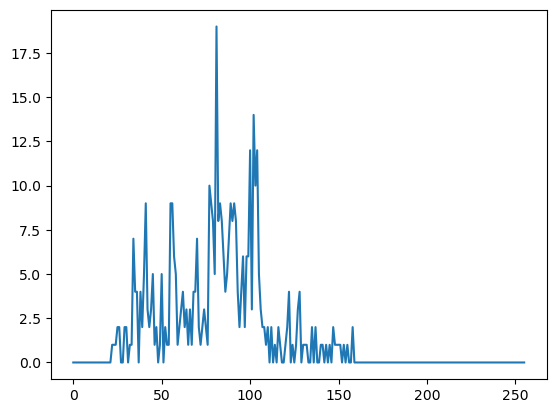

In [446]:
hist = cv2.calcHist(img_grey, [0], None, [256], [0,255])
plt.plot(hist)

In [447]:
# Performing Binary thresholding
_, thresh_binary = cv2.threshold(img_grey, 130, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
opening = cv2.morphologyEx(thresh_binary, cv2.MORPH_OPEN, kernel)
closeing = cv2.morphologyEx(thresh_binary, cv2.MORPH_CLOSE, kernel)
open_close = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)
kernel = np.ones((11,11), np.uint8)
dilate = cv2.morphologyEx(thresh_binary, cv2.MORPH_DILATE, kernel)

In [448]:
# Finding Contour
contours, _ = cv2.findContours(thresh_binary, mode = cv2.RETR_EXTERNAL, method = cv2.CHAIN_APPROX_SIMPLE)

In [449]:
# Creating image copy to show contours
img_copy = img.copy()
img_copy = cv2.drawContours(img_copy, contours, -1, (0,255,0), thickness = 2, lineType = cv2.LINE_AA)

In [450]:
# Finding the countour with max length 
max_cont = max(contours, key = cv2.contourArea)

# Finding the coordinated of the bounding box
x,y,w,h = cv2.boundingRect(max_cont)

In [470]:
# Creating the bounding box on image
img_bound = cv2.rectangle(img_copy, (x,y), (x+w, y+h), (0, 0 , 255), 2)
img_bound = cv2.circle(img_bound, (x+(w//2),y+(h//2)), 5, (255, 0, 0), -1)

In [478]:
# extracting the bounded region
img_extract = img[y:y+h, x:x+w]

In [480]:
cv2.imshow('greyscale',img_grey)
cv2.imshow('binary',thresh_binary)
cv2.imshow('contours',img_copy)
cv2.imshow('bounding_area',img_bound)
cv2.imshow('extracted image',img_extract)

# cv2.imshow('open',opening)
# cv2.imshow('close',closeing)
# cv2.imshow('open close',open_close)
# cv2.imshow('dilate',dilate)

if cv2.waitKey(0) & 0xff == ord('q'):
    cv2.destroyAllWindows()